# Human Action Detection Using Machine Learning

### Internship Project 1

**Submitted By:** Chirashree Mallick

**Domain:** Machine Learning Mentorship Program

**Organization:** 1Stop.ai

**Dataset Used:** Human Activity Recognition Using Smartphones Dataset

**Problem Type:** Multi-Class Classification

**Machine Learning Techniques / Algorithms Used:**
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree Classifier
- Feature Scaling (RobustScaler)
- Classification Evaluation Metrics

**Objective:**
To classify human activities using smartphone sensor measurements and machine learning algorithms.

# Problem Statement

Human Action Detection is a machine learning classification problem where the objective is to identify and classify different human activities using sensor data collected from smartphones.

In this project, smartphone sensor measurements are used to detect activities such as Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, and Laying.

The goal is to build machine learning models capable of accurately classifying human activities through data preprocessing, feature scaling, model training, and performance evaluation.

# Importing Required Libraries

In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Loading the Dataset

In [21]:
df = pd.read_csv("train.csv")

print(df.shape)

df.head()

(7352, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


# Initial Data Exploration

In [22]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


# Checking Missing Values and Duplicate Records

In [23]:
print("Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
0


# Exploratory Data Analysis

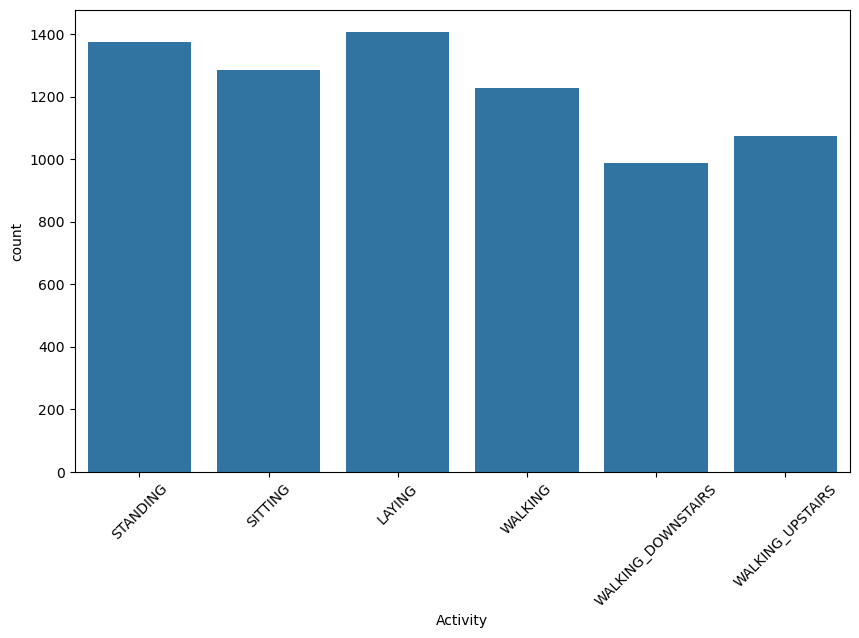

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Activity',
    data=df
)

plt.xticks(rotation=45)

plt.show()

# Activity Distribution Analysis

In [25]:
df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

# Label Encoding

In [26]:
le = LabelEncoder()

df['Activity'] = le.fit_transform(
    df['Activity']
)

df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,2
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,2
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,2
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,2
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,2


# Feature Selection

In [27]:
X = df.drop(
    ['Activity', 'subject'],
    axis=1
)

y = df['Activity']
print(X.shape)
print(y.shape)

(7352, 561)
(7352,)


# Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(5514, 561)
(1838, 561)


# Feature Scaling Using RobustScaler

In [29]:
scaler = RobustScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)
print(X_train.shape)

(5514, 561)


# Model Evaluation Utility Function

In [30]:
def result_summarizer(y_true, y_pred):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    print(classification_report(
        y_true,
        y_pred
    ))

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred,
            average='macro'
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred,
            average='macro'
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_true,
            y_pred,
            average='macro'
        )
    )

# Logistic Regression Model

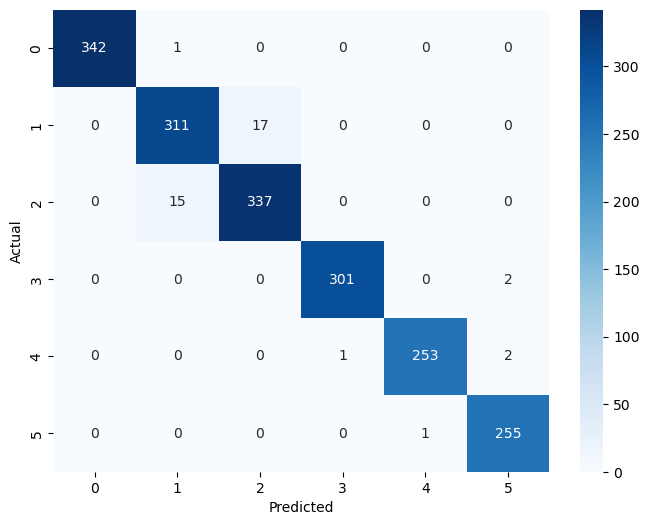

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       0.95      0.95      0.95       328
           2       0.95      0.96      0.95       352
           3       1.00      0.99      1.00       303
           4       1.00      0.99      0.99       256
           5       0.98      1.00      0.99       256

    accuracy                           0.98      1838
   macro avg       0.98      0.98      0.98      1838
weighted avg       0.98      0.98      0.98      1838

Accuracy: 0.9787812840043526
Precision: 0.9800592426542006
Recall: 0.9800693305637718
F1 Score: 0.980053689125722


In [31]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

result_summarizer(
    y_test,
    y_pred_lr
)

# K-Nearest Neighbors (KNN) Model

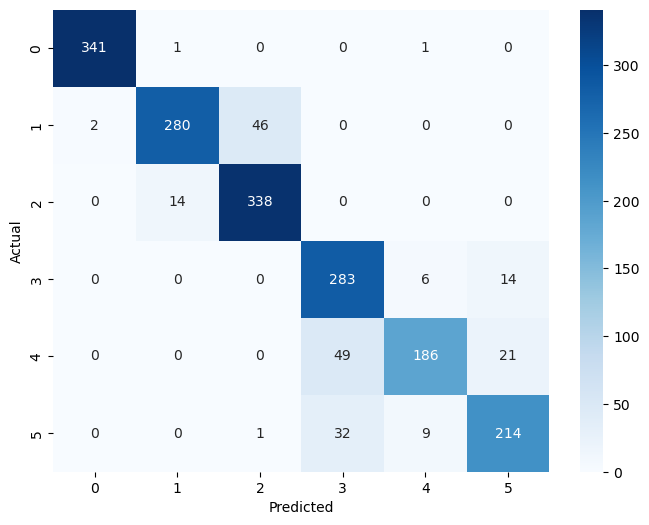

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       343
           1       0.95      0.85      0.90       328
           2       0.88      0.96      0.92       352
           3       0.78      0.93      0.85       303
           4       0.92      0.73      0.81       256
           5       0.86      0.84      0.85       256

    accuracy                           0.89      1838
   macro avg       0.90      0.88      0.89      1838
weighted avg       0.90      0.89      0.89      1838

Accuracy: 0.8933623503808488
Precision: 0.8964910123648894
Recall: 0.8840913841437477
F1 Score: 0.886434176878152


In [32]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test
)

result_summarizer(
    y_test,
    y_pred_knn
)

# Decision Tree Classifier

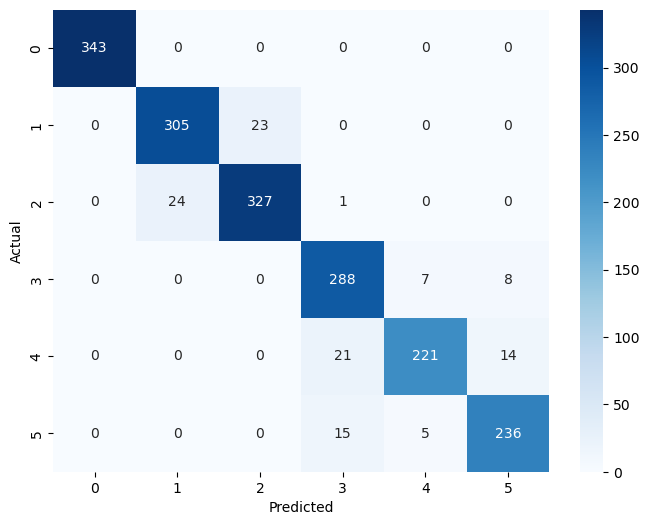

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       0.93      0.93      0.93       328
           2       0.93      0.93      0.93       352
           3       0.89      0.95      0.92       303
           4       0.95      0.86      0.90       256
           5       0.91      0.92      0.92       256

    accuracy                           0.94      1838
   macro avg       0.94      0.93      0.93      1838
weighted avg       0.94      0.94      0.94      1838

Accuracy: 0.9357997823721437
Precision: 0.9351196280699798
Recall: 0.9324177701687851
F1 Score: 0.9332429185756078


In [33]:
dt = DecisionTreeClassifier(
    max_depth=14,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(
    X_test
)

result_summarizer(
    y_test,
    y_pred_dt
)

# Model Comparison

The performance of Logistic Regression, K-Nearest Neighbors (KNN), and Decision Tree Classifier is compared using classification accuracy.

The comparison helps identify the most suitable machine learning model for Human Action Detection based on overall predictive performance.

In [34]:
models = ['Logistic Regression', 'KNN', 'Decision Tree']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison

,Model,Accuracy
0,Logistic Regression,0.978781
1,KNN,0.893362
2,Decision Tree,0.935800


# Best Performing Model

In [35]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy               0.978781
Name: 0, dtype: object


## Conclusion

In this project, machine learning techniques were applied to classify human activities using smartphone sensor data. Data preprocessing, exploratory data analysis, label encoding, feature scaling, and model training were successfully performed.

Three classification algorithms namely Logistic Regression, K-Nearest Neighbors (KNN), and Decision Tree Classifier were implemented and evaluated using confusion matrices, classification reports, accuracy, precision, recall, and F1-score metrics.

Among the evaluated models, **Logistic Regression** achieved the highest classification accuracy and demonstrated excellent capability in recognizing human activities. The model effectively classified activities such as walking, sitting, standing, laying, and stair movement using smartphone sensor measurements.

The results confirm that machine learning algorithms can accurately detect and classify human actions and can be applied in healthcare monitoring, fitness tracking, wearable devices, and intelligent activity recognition systems.

The project successfully fulfills the objective of Human Action Detection and demonstrates the practical implementation of supervised machine learning techniques for multi-class classification problems.